In [91]:
from pathlib import Path

from PIL import Image

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()

  return df

In [93]:
data_dir = Path('../blockies_datasets/simple/bend_only')
dataset = 'train'

df = load_dataframe(data_dir, dataset)

In [94]:
(df.ill == 0).sum()

np.int64(6)

In [95]:
df.sample(5)

,obj_name,labeling_error,spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,...,ill_chars,main_spherical,sec_spherical,num_sec_bones,label,__module__,__name__,filename,ill,sphere_diff
16,ocd,False,0.5,0.326546,0.016946,0.138398,-1.651892,False,-0.178260,-0.061736,...,[high_bend],0.300732,0.916166,1,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,616af8ca-a944-461b-a358-e7359e768275.png,1,0.615434
10,ocd,False,0.5,0.286509,-0.003569,0.043851,-2.558332,False,-0.259752,-0.253393,...,[high_bend],0.004799,0.596965,3,ocd,blockies.blocky_scene_parameters,BlockySceneParameters,ef86c9b7-fe81-4680-8d23-171be432262b.png,1,0.592166
0,healthy,False,0.5,0.069340,-0.023853,0.100245,-2.107345,False,-0.380480,-0.196233,...,[],0.993164,0.446149,2,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,d33f25ec-5d40-4282-bb4d-cb083ddb79ec.png,0,0.547015
1,healthy,False,0.5,0.122532,-0.007590,-0.107757,-1.134940,False,-0.685571,-0.781168,...,[],0.054985,0.576221,3,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,3c773130-29bc-4231-9294-c89b91e07f77.png,0,0.521235
5,healthy,False,0.5,0.016988,-0.019163,0.021395,-2.139044,False,-0.144568,-0.412536,...,[],0.064749,0.746560,2,healthy,blockies.blocky_scene_parameters,BlockySceneParameters,9b5b0be5-beb7-4ec5-83af-0cd9fc91e219.png,0,0.681811


In [96]:
df.columns

Index(['obj_name', 'labeling_error', 'spherical', 'bending',
       'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr',
       'position_x', 'position_y', 'arm_position', 'obj_color',
       'obj_color_rgba', 'bg_color', 'bg_color_rgba', 'resolution',
       'ill_spherical', 'num_diff', 'id', 'original_id', '_attributes_status',
       'num_ill_chars', 'ill_chars', 'main_spherical', 'sec_spherical',
       'num_sec_bones', 'label', '__module__', '__name__', 'filename', 'ill',
       'sphere_diff'],
      dtype='object')

<Axes: xlabel='bending', ylabel='Count'>

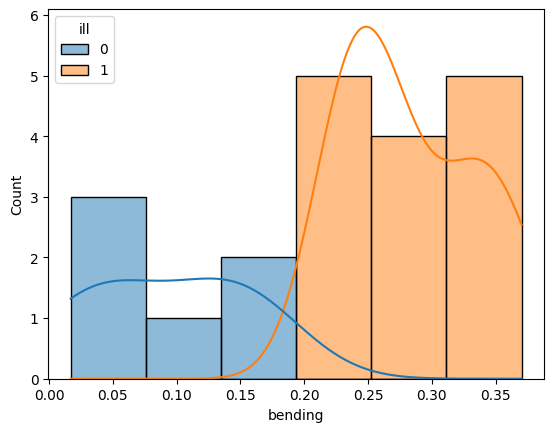

In [97]:
sns.histplot(data=df, x='bending', hue='ill', kde=True)

<Axes: xlabel='main_spherical', ylabel='Count'>

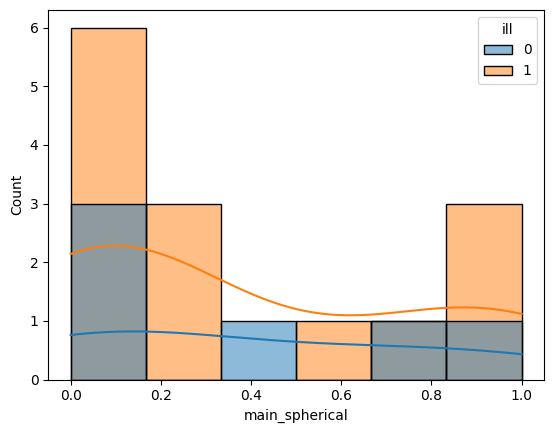

In [98]:
sns.histplot(data=df, x='main_spherical', hue='ill', kde=True)

<Axes: xlabel='sec_spherical', ylabel='Count'>

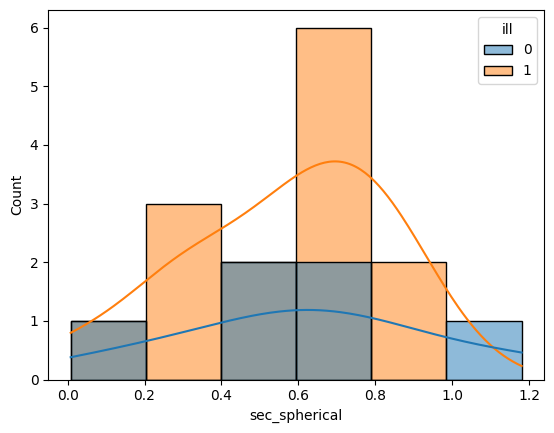

In [99]:
sns.histplot(data=df, x='sec_spherical', hue='ill', kde=True)

<Axes: xlabel='sphere_diff', ylabel='Count'>

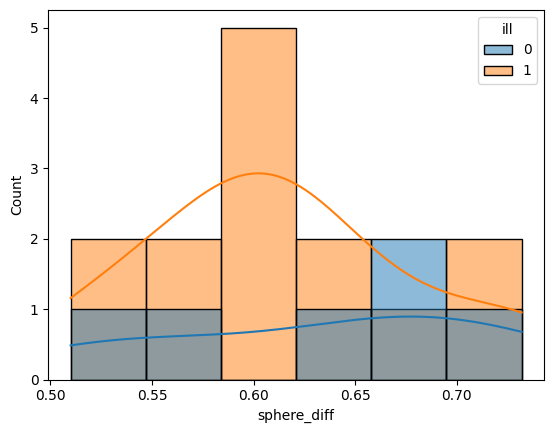

In [100]:
sns.histplot(data=df, x='sphere_diff', hue='ill', kde=True)

<Axes: xlabel='num_sec_bones', ylabel='Count'>

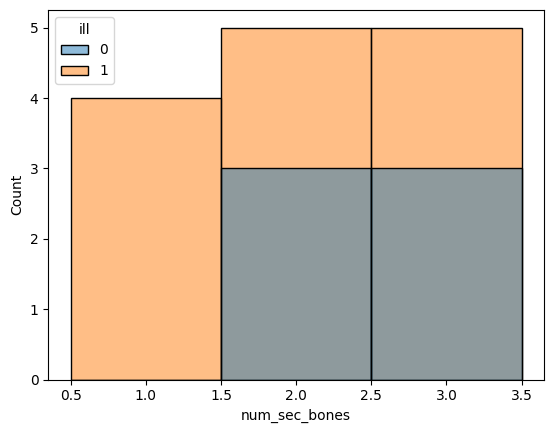

In [101]:
sns.histplot(data=df, x='num_sec_bones', hue='ill', kde=False, discrete=True)

<Axes: xlabel='arm_position', ylabel='Density'>

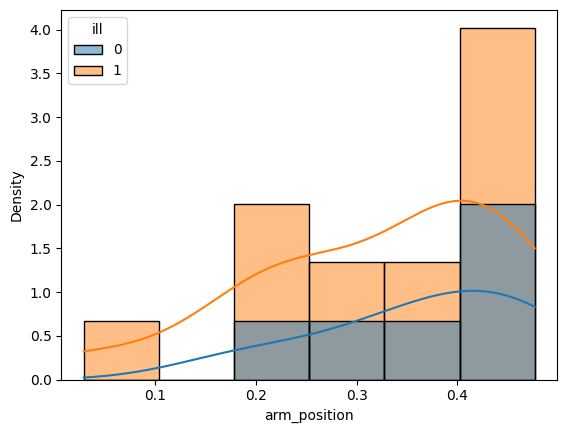

In [106]:
sns.histplot(data=df, x='arm_position', hue='ill', kde=True, stat='density')

In [102]:
def load_imgs(paths):
  imgs = []
  for path in paths:
      img = Image.open(path).convert('RGB')
      imgs.append(img)
  return imgs

In [103]:
notill_samples = df[df.ill == 0].sample(6)
paths = notill_samples.filename.apply(lambda x: data_dir / dataset / x)
notill_imgs = load_imgs(paths)
ill_samples = df[df.ill == 1].sample(6)
paths = ill_samples.filename.apply(lambda x: data_dir / dataset / x)
ill_imgs = load_imgs(paths)

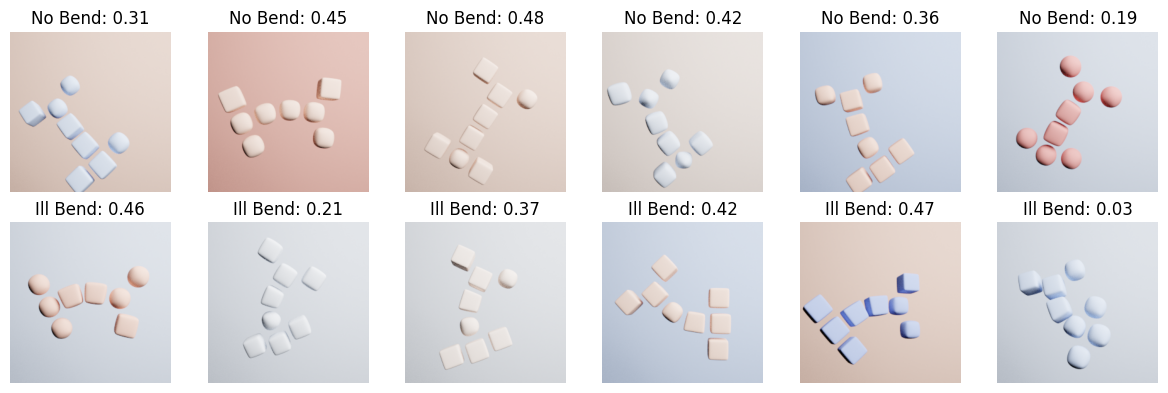

In [107]:
axes = plt.subplots(2, 6, figsize=(12, 4))[1]
for i, img in enumerate(notill_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'No Bend: {notill_samples.iloc[i].arm_position:.2f}')
for i, img in enumerate(ill_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Ill Bend: {ill_samples.iloc[i].arm_position:.2f}')
plt.tight_layout()
plt.show()